In [1]:
# cell 1
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, v_measure_score

from IPython.display import display, Audio

In [ ]:
# cell 2: auto-reloads project modules (duet_ms, duet_opt, etc.) when they change, 
# so no need to restart the kernel after pull
%load_ext autoreload
%autoreload 2

In [3]:
# cell 3
from duet_opt import init_data, DATA
from duet_ms import DuetMS
from source_generation import display_results

In [ ]:
# cell 4: generate synthetic test data: loads audio files and creates 10 samples
# with known attenuations and delays (ground truth for scoring).
init_data()
print(f"Number of samples loaded: {len(DATA)}")

['plastic_crumpling: s=36541, a=1.26, d=-3.60, rms=-21.07', 'plastic_crumpling: s=6497, a=1.19, d=-4.43, rms=-23.66']
['chewing_gum: s=47725, a=1.11, d=-6.50, rms=-39.43', 'plastic_crumpling: s=43390, a=1.06, d=-4.28, rms=-25.05']
['chewing_gum: s=20013, a=1.51, d=-0.65, rms=-38.56', 'plastic_crumpling: s=41998, a=0.66, d=-6.00, rms=-30.56']
['human_breathing: s=44720, a=0.72, d=-0.75, rms=-21.74', 'plastic_crumpling: s=18296, a=0.87, d=5.35, rms=-29.75']
['human_breathing: s=33517, a=1.24, d=6.61, rms=-29.44', 'human_breathing: s=26728, a=0.75, d=1.07, rms=-27.71']
['chewing_gum: s=28877, a=1.04, d=-5.77, rms=-33.76', 'water_drops: s=39042, a=1.28, d=3.92, rms=-14.99']
['typing: s=33606, a=1.44, d=-0.74, rms=-21.32', 'chewing_gum: s=12508, a=0.79, d=7.26, rms=-26.66']
['chewing_gum: s=44642, a=0.66, d=6.49, rms=-38.05', 'human_breathing: s=32612, a=0.77, d=5.75, rms=-23.12']
['clearing_throat: s=31796, a=1.08, d=3.57, rms=-25.05', 'basketball_dribbling: s=27477, a=0.78, d=6.12, rms=-3

In [ ]:
# cell 5: parameters below are arbitrary defaults for exploration only, not optimized.
# The grid search in duet_opt.py will find the best combination.
ind = 0  # hangi örneğe bakıyoruz (0-9 arası)

my_params = {
    "audio_length": 96,
    "window": 256,
    "oversample": 1,
    "threshold": 0.5,
    "bandwidth": 0.2,
    "alpha_max": 1.5,
    "delta_max": 8.5,
    "seed_count": 25,
    "min_bin_count": 5,
    "max_filter_size": None,
    "compute_seeds_using_weights": False,
    "convergence_tol": 0.2,
    "alpha_op": "symmetric",
    "big_delay": "diff",
    "delta_smoothing": (3, 1),
    "delta_smoothing_mode": "mean",
    "p": 1,
    "q": 0,
}

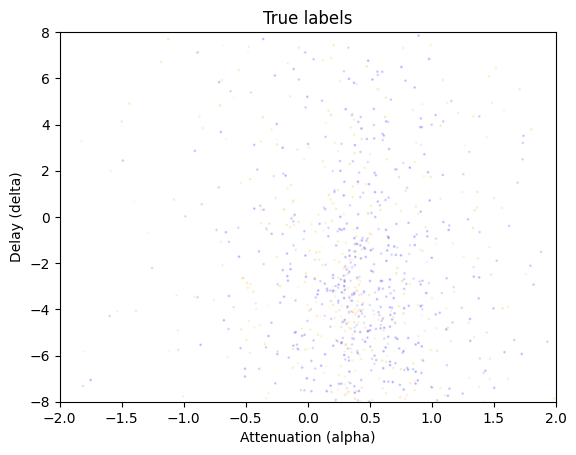

In [6]:
# cell 6: jeff code from google chat
# prepare parameters
this_params = my_params.copy()
audio_length = this_params.pop("audio_length")

# create DUET object and compute
duet = DuetMS(16000, **this_params)
tf, tf_weights, alpha, delta = duet._compute_all(
    duet._normalize_data(DATA[ind][0][:, :audio_length*16000//1000])
)

# compute true labels (which TF point belongs to which source?)
best, sources = duet._compute_sources(
    tf,
    np.array(DATA[ind][1]),  # true attenuations
    np.array(DATA[ind][2])   # true delays
)

# flatten
alpha_flat = alpha.flatten()
delta_flat = delta.flatten()
best_flat = best.flatten()
tfw_flat = tf_weights.flatten()

# visualize-> blue: source 0, orange: source 1
plt.figure()
display_results(alpha_flat[best_flat == 0], delta_flat[best_flat == 0], tfw_flat[best_flat == 0], color='blue')
display_results(alpha_flat[best_flat == 1], delta_flat[best_flat == 1], tfw_flat[best_flat == 1], color='orange')
plt.title("True labels")
plt.show()

In [7]:
# cell 7:  find peaks predicted by the algorithm then assign each TF point to its nearest predicted peak
alpha_peaks, delta_peaks = duet._find_peaks(tf_weights, alpha, delta)
print(f"Number of peaks found: {len(alpha_peaks)}")
print(f"Alpha peaks: {alpha_peaks}")
print(f"Delta peaks: {delta_peaks}")

# alpha_peaks is in symmetric alpha — _compute_sources expects attenuation
alpha_peaks_atn = duet._convert_alpha_to_atn(alpha_peaks)

# assign each TF point to nearest predicted peak
best_pred, _ = duet._compute_sources(tf, alpha_peaks_atn, delta_peaks)
pred_flat = best_pred.flatten()

Number of peaks found: 3
Alpha peaks: [0.20746795 0.5157677  0.54046414]
Delta peaks: [-3.21590251 -1.38890322 -4.850681  ]


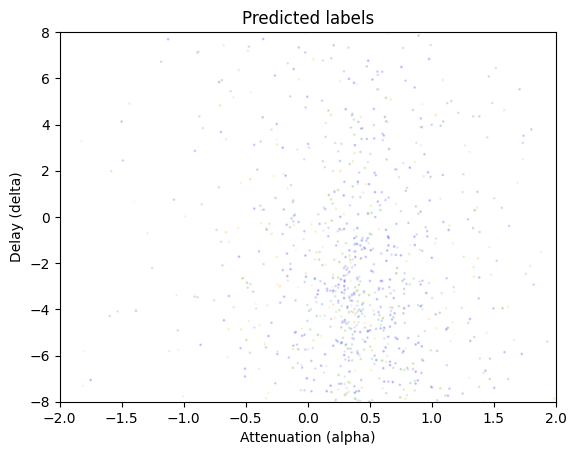

In [8]:
# cell 8: visualize predicted cluster assignments. each color represents a different predicted source.
colors = ['blue', 'orange', 'green', 'red', 'purple']

plt.figure()
for i in range(len(alpha_peaks)):
    display_results(
        alpha_flat[pred_flat == i],
        delta_flat[pred_flat == i],
        tfw_flat[pred_flat == i],
        color=colors[i]
    )
plt.title("Predicted labels")
plt.show()

In [9]:
# cell 9: compare true vs predicted cluster assignments using standard clustering metrics.
# ARI, NMI, and V-Measure all range 0 - 1.
ari = adjusted_rand_score(best_flat, pred_flat)
nmi = normalized_mutual_info_score(best_flat, pred_flat)
vm  = v_measure_score(best_flat, pred_flat)

print(f"True sources     : {len(np.unique(best_flat))}")
print(f"Predicted sources: {len(np.unique(pred_flat))}")
print(f"---")
print(f"0 (random) to 1 (perfect)")

# (Adjusted Rand Index): measures overlap between true and predicted assignments,
# adjusted for chance. Robust to different cluster counts.
print(f"ARI      : {ari:.4f}") 

# NMI (Normalized Mutual Information): measures shared information between true and
# predicted assignments, normalized to [0, 1].
print(f"NMI      : {nmi:.4f}")

# V-Measure: harmonic mean of homogeneity and completeness, 
# are predicted clusters pure, and do they cover all true sources?
print(f"V-Measure: {vm:.4f}")

True sources     : 2
Predicted sources: 3
---
0 (random) to 1 (perfect)
ARI      : 0.4505
NMI      : 0.3876
V-Measure: 0.3876


In [10]:
# cell 10
results = []

for ind in range(len(DATA)):
    this_params = my_params.copy()
    audio_length = this_params.pop("audio_length")
    
    duet = DuetMS(16000, **this_params)
    tf, tf_weights, alpha, delta = duet._compute_all(
        duet._normalize_data(DATA[ind][0][:, :audio_length*16000//1000])
    )
    
    # actual
    best_true, _ = duet._compute_sources(
        tf, np.array(DATA[ind][1]), np.array(DATA[ind][2])
    )
    
    # guessed 
    try:
        alpha_peaks, delta_peaks = duet._find_peaks(tf_weights, alpha, delta)
        alpha_peaks_atn = duet._convert_alpha_to_atn(alpha_peaks)
        best_pred, _ = duet._compute_sources(tf, alpha_peaks_atn, delta_peaks)
        
        ari = adjusted_rand_score(best_true.flatten(), best_pred.flatten())
        nmi = normalized_mutual_info_score(best_true.flatten(), best_pred.flatten())
        vm  = v_measure_score(best_true.flatten(), best_pred.flatten())
        n_pred = len(alpha_peaks)
    except Exception as e:
        ari, nmi, vm, n_pred = float('nan'), float('nan'), float('nan'), 0
        print(f"Sample {ind} error: {e}")
    
    results.append({"ind": ind, "n_true": 2, "n_pred": n_pred, "ari": ari, "nmi": nmi, "vm": vm})
    print(f"Sample {ind}: n_pred={n_pred}, ARI={ari:.4f}, NMI={nmi:.4f}")
print(f"\nMean ARI: {np.nanmean([r['ari'] for r in results]):.4f}")
print(f"Mean NMI: {np.nanmean([r['nmi'] for r in results]):.4f}")

Sample 0: n_pred=3, ARI=0.4505, NMI=0.3876
Sample 1: n_pred=3, ARI=0.2892, NMI=0.1896
Sample 2: n_pred=3, ARI=0.3178, NMI=0.1468
Sample 3: n_pred=1, ARI=0.0000, NMI=0.0000
Sample 4: n_pred=6, ARI=0.2094, NMI=0.2071
Sample 5: n_pred=3, ARI=0.0699, NMI=0.0252
Sample 6: n_pred=1, ARI=0.0000, NMI=0.0000
Sample 7: n_pred=7, ARI=0.1568, NMI=0.1202
Sample 8 error: attempt to get argmin of an empty sequence
Sample 8: n_pred=0, ARI=nan, NMI=nan
Sample 9: n_pred=1, ARI=0.0000, NMI=0.0000

Mean ARI: 0.1660
Mean NMI: 0.1196
